In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)


# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/competitions/smart-mcq-solver-challenge/sample_submission.csv
/kaggle/input/competitions/smart-mcq-solver-challenge/train.csv
/kaggle/input/competitions/smart-mcq-solver-challenge/test.csv


# Data Loading 

In [2]:
df=pd.read_csv("/kaggle/input/competitions/smart-mcq-solver-challenge/train.csv")
test_df=pd.read_csv("/kaggle/input/competitions/smart-mcq-solver-challenge/test.csv")


# Inspection of Data

In [3]:
df.head()

,id,prompt,A,B,C,D,E,answer
0,1,Pick the best possible answer: What is Martin ...,Martin Heidegger believes that humans exist wi...,Martin Heidegger believes that humans do not e...,Martin Heidegger does not believe in the exist...,Martin Heidegger believes that the relationshi...,Martin Heidegger believes that time is an illu...,B
1,2,What is accelerator-based light-ion fusion?,Accelerator-based light-ion fusion is a techni...,Accelerator-based light-ion fusion is a techni...,Accelerator-based light-ion fusion is a techni...,Accelerator-based light-ion fusion is a techni...,Accelerator-based light-ion fusion is a techni...,A
2,3,Determine the correct option: What is the term...,Blueshifting,Redshifting,Reddening,Whitening,Yellowing,C
3,4,Select the most accurate option: What is Marti...,Martin Heidegger believes that humans exist wi...,Martin Heidegger believes that humans do not e...,Martin Heidegger does not believe in the exist...,Martin Heidegger believes that the relationshi...,Martin Heidegger believes that time is an illu...,B
4,5,Identify the correct statement: What is the co...,"Simultaneity is relative, meaning that two eve...","Simultaneity is relative, meaning that two eve...","Simultaneity is absolute, meaning that two eve...",Simultaneity is a concept that applies only to...,Simultaneity is a concept that applies only to...,A


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 8 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   id      2000 non-null   int64 
 1   prompt  2000 non-null   object
 2   A       2000 non-null   object
 3   B       2000 non-null   object
 4   C       2000 non-null   object
 5   D       2000 non-null   object
 6   E       2000 non-null   object
 7   answer  2000 non-null   object
dtypes: int64(1), object(7)
memory usage: 125.1+ KB


Conclusion : Need of Encoding 

In [5]:
df.shape

(2000, 8)

In [6]:
df.isna().sum()

id        0
prompt    0
A         0
B         0
C         0
D         0
E         0
answer    0
dtype: int64

In [7]:
df=df.drop(columns="id")

In [8]:
df.duplicated().sum()

np.int64(183)

In [9]:
(df['answer'].value_counts()/df.shape[0])*100

answer
B    24.50
C    22.95
A    18.45
D    17.90
E    16.20
Name: count, dtype: float64

<Axes: xlabel='answer', ylabel='count'>

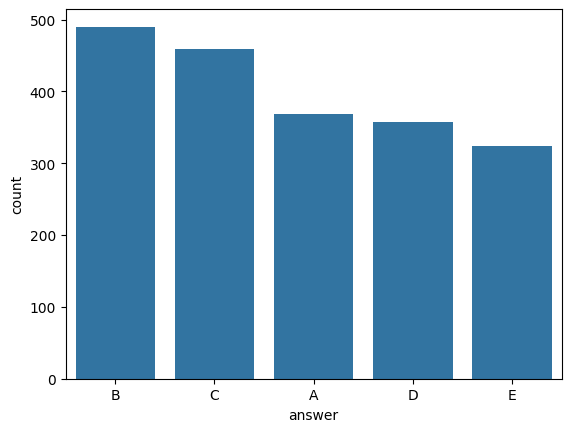

In [10]:
import seaborn as sns

sns.countplot(x=df['answer'], data=df, order=df['answer'].value_counts().index)

In [11]:
x=df['answer'].value_counts().max() +  df['answer'].value_counts().min()

print("Sum of Most frequent and least frequent options in answer column =",x)

Sum of Most frequent and least frequent options in answer column = 814


# Train Test Split

# Data cleaning 
Creating Vocab 
* removing punctuation
* split by space 

In [12]:
import string
has_punctuation = df["prompt"].apply(
    lambda text: any(c in string.punctuation for c in text)
)
print(has_punctuation.unique())

[ True]


In [13]:
import string
def clean_text(text):
    text=text.lower()
    text=text.strip()
    translator=str.maketrans('','',string.punctuation) #nothing,nothing,delete punctuation 
    text=text.translate(translator)
    return text
    

In [14]:
for col in ["prompt", "A", "B", "C", "D", "E"]:
    df[col] = df[col].apply(clean_text)
    test_df[col]=test_df[col].apply(clean_text)

In [15]:
#verifying 
has_punctuation = df["prompt"].apply(
    lambda text: any(c in string.punctuation for c in text)
)
print(has_punctuation.unique())

[False]


In [16]:
from sklearn.model_selection import train_test_split

X = df.drop(["answer"],axis=1)
y = df['answer']

X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [17]:
df.duplicated().sum()
df = df.drop_duplicates()

# Map@3 Metric 


In [18]:
def map3(y_true, top3_preds):
    score = 0

    for actual, pred in zip(y_true, top3_preds):
        if actual == pred[0]:
            score += 1.0

        elif actual == pred[1]:
            score += 0.5

        elif actual == pred[2]:
            score += 1/3

    return score / len(y_true)

# Base line model 

In [19]:
counts = df['answer'].value_counts()

top3 = counts.index[:3].tolist()

print(top3)

['B', 'C', 'D']


In [20]:
y_pred = [top3] * len(X_train)

In [21]:
print("Majority class baseline : ",round(map3(y_train,y_pred),3)) #train dataset and its a dummy classifier

Majority class baseline :  0.419


# Tfidf + cosine similarity 

In [22]:
train_text=pd.concat([
    X_train["prompt"],
    X_train["A"],
    X_train["B"],
    X_train["C"],
    X_train["D"],
    X_train["E"]
])

In [23]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer= TfidfVectorizer( ngram_range=(1,3), lowercase=False,
    max_features=80000,
    min_df=2,stop_words="english")
vectorizer.fit(train_text)


TfidfVectorizer(lowercase=False, max_features=80000, min_df=2,
                ngram_range=(1, 3), stop_words='english')

In [24]:
def transform_columns(df,vectorizer):
    return (
        vectorizer.transform(df["prompt"]),
        vectorizer.transform(df["A"]),
        vectorizer.transform(df["B"]),
        vectorizer.transform(df["C"]),
        vectorizer.transform(df["D"]),
        vectorizer.transform(df["E"])
    )

In [25]:
prompt_vec, A_vec, B_vec, C_vec, D_vec, E_vec = transform_columns(X_train, vectorizer)

prompt_val, A_val, B_val, C_val, D_val, E_val = transform_columns(X_val, vectorizer)


In [26]:
from sklearn.metrics.pairwise import cosine_similarity
print("shape of comparing prompt with A_vector",cosine_similarity(prompt_vec, A_vec).diagonal().shape)
scores = {
    'A': cosine_similarity(prompt_vec, A_vec).diagonal(),
    'B': cosine_similarity(prompt_vec, B_vec).diagonal(),
    'C': cosine_similarity(prompt_vec, C_vec).diagonal(),
    'D': cosine_similarity(prompt_vec, D_vec).diagonal(),
    'E': cosine_similarity(prompt_vec, E_vec).diagonal()
}
scores_val = {
    'A': cosine_similarity(prompt_val, A_val).diagonal(),
    'B': cosine_similarity(prompt_val, B_val).diagonal(),
    'C': cosine_similarity(prompt_val, C_val).diagonal(),
    'D': cosine_similarity(prompt_val, D_val).diagonal(),
    'E': cosine_similarity(prompt_val, E_val).diagonal()
}



shape of comparing prompt with A_vector (1600,)


In [27]:
def top3preds(scores_dict):
    preds = []

    for i in range(len(scores_dict["A"])):

        row_scores = {
            "A": scores_dict["A"][i],
            "B": scores_dict["B"][i],
            "C": scores_dict["C"][i],
            "D": scores_dict["D"][i],
            "E": scores_dict["E"][i]
        }

        top3 = []

        for k in range(3):

            best_opt = None
            best_score = -1

            for option, score in row_scores.items():

                if score > best_score:
                    best_score = score
                    best_opt = option

            top3.append(best_opt)
            row_scores.pop(best_opt)

        preds.append(top3)

    return preds

top3_list_val=top3preds(scores_val)
top3_list_train=top3preds(scores)

In [28]:
map3(y_train,top3_list_train)

0.3379166666666659

In [29]:
map3(y_val,top3_list_val)

0.3054166666666664

**Conclusion** Tfidf + cosine similarity gives 0.28 map@3 score on unknown data 

### LR model 
 

In [30]:
from sklearn.linear_model import LogisticRegression

Converting prompt to prompt+option format with label and when prompt and  true option is paired then gives label as 1 . thus converted multiclass labels to binary class labels 

In [31]:
def expand_to_binary(X, y):
    rows = []
    for (idx, row), label in zip(X.iterrows(), y):
        for opt in ['A', 'B', 'C', 'D', 'E']:
            rows.append({
                'text': row['prompt'] + ' ' + row[opt],
                'label': 1 if label == opt else 0
            })
    return pd.DataFrame(rows)


In [32]:

train_binary = expand_to_binary(X_train, y_train)
print("Train binary shape:", train_binary.shape)
print(train_binary['label'].value_counts())


Train binary shape: (8000, 2)
label
0    6400
1    1600
Name: count, dtype: int64


In [33]:

X_train_vec = vectorizer.fit_transform(train_binary['text'])  # fit ONLY on train

lr = LogisticRegression(max_iter=1000)
lr.fit(X_train_vec, train_binary['label'])


LogisticRegression(max_iter=1000)

In [34]:

#  INFERENCE 
def predict_top3(row):

    options = ["A", "B", "C", "D", "E"]

    texts = []

    for option in options:
        texts.append(row["prompt"] + " " + row[option])

    probs = lr.predict_proba(vectorizer.transform(texts))[:, 1]

    scores = []

    for i in range(5):
        scores.append((options[i], probs[i]))

    scores.sort(key=lambda x: x[1], reverse=True)

    return [scores[0][0], scores[1][0], scores[2][0]]


In [35]:

top3_val = [predict_top3(row) for _, row in X_val.iterrows()]
print("Validation MAP@3:", round(map3(y_val, top3_val), 4))


Validation MAP@3: 0.9846


## Conclusion of lr model

The **0.9454** validation score reflects lexical memorization of training patterns, not true understanding. The **0.75** leaderboard score reflects real-world generalization. This gap motivates moving towards dl models for better generalization.

## Dl model 

In [36]:
from sklearn.model_selection import train_test_split
import wandb
from kaggle_secrets import UserSecretsClient
import torch

In [37]:
df=pd.read_csv("/kaggle/input/competitions/smart-mcq-solver-challenge/train.csv")
df = df.drop(columns=["id"])
print("df intialized")

df intialized


In [38]:


print(wandb.__version__)

user_secrets = UserSecretsClient()
secret_value_0 = user_secrets.get_secret("WANDB_API_KEY")
wandb.login(secret_value_0)
wandb.init( project="23f2005464-t22026", entity="23f2005464-iit-madras-",   name="bert-baseline")

wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: [wandb.login()] Using explicit session credentials for https://api.wandb.ai.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc


0.25.1


wandb: Currently logged in as: 23f2005464 (23f2005464-iit-madras-) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin
wandb: Tracking run with wandb version 0.25.1
wandb: Run data is saved locally in /kaggle/working/wandb/run-20260723_063343-4pnyskpv
wandb: Run `wandb offline` to turn off syncing.
wandb: Syncing run bert-baseline
wandb: ⭐️ View project at https://wandb.ai/23f2005464-iit-madras-/23f2005464-t22026
wandb: 🚀 View run at https://wandb.ai/23f2005464-iit-madras-/23f2005464-t22026/runs/4pnyskpv


In [39]:
import string
def clean_text(text):
    text=text.lower()
    text=text.strip()
    translator=str.maketrans('','',string.punctuation) #nothing,nothing,delete punctuation 
    text=text.translate(translator)
    return text
    

In [40]:
for col in ["prompt", "A", "B", "C", "D", "E"]:
    df[col] = df[col].apply(clean_text)

In [41]:
OPTIONS = ["A", "B", "C", "D", "E"]
LABEL2ID = {opt: i for i, opt in enumerate(OPTIONS)}

# encode answer letter -> integer 0-4
df["label"] = df["answer"].map(LABEL2ID)
assert df["label"].isnull().sum() == 0, "Found answer values outside A-E"

torch.manual_seed(42)
np.random.seed(42)


In [42]:

train_df, val_df = train_test_split(
    df,
    test_size=0.2,
    random_state=42,
    stratify=df["label"],
)
train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)

print(f"Train size: {len(train_df)} | Val size: {len(val_df)}")

Train size: 1600 | Val size: 400


In [43]:
from transformers import (
    BertTokenizerFast,
    BertForMultipleChoice,
    TrainingArguments,
    Trainer,
)

MODEL_NAME="bert-base-uncased"
tokenizer = BertTokenizerFast.from_pretrained(MODEL_NAME)


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [44]:
from torch.utils.data import Dataset
class MCQDataset(Dataset):
    def __init__(self, dataframe: pd.DataFrame, tokenizer, max_len: int):
        self.df = dataframe
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        prompt = row["prompt"]
        options = [row[opt] for opt in OPTIONS]

        # first_sentences repeated 5x, second_sentences = each option
        first_sentences = [prompt] * len(OPTIONS)
        second_sentences = options

        encoding = self.tokenizer(
            first_sentences,
            second_sentences,
            truncation=True,
            max_length=self.max_len,
            padding="max_length",
            return_tensors="pt",
        )
        # encoding['input_ids'] shape: [5, max_len] -> exactly what the model wants
        item = {k: v for k, v in encoding.items()}
        item["labels"] = torch.tensor(row["label"], dtype=torch.long)
        return item

In [45]:

train_dataset = MCQDataset(train_df, tokenizer, 128)
val_dataset = MCQDataset(val_df, tokenizer, 128)


In [46]:
model = BertForMultipleChoice.from_pretrained(MODEL_NAME)


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForMultipleChoice LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.weight                | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [47]:

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)
    accuracy = (preds == labels).mean()
    # build top-3 prediction lists (ranked by logit score, highest first)
    top3_preds = np.argsort(-logits, axis=1)[:, :3].tolist()
    map3_score = map3(labels.tolist(), top3_preds)
    return {"accuracy": accuracy, "map@3": map3_score}

In [48]:
import torch 
training_args = TrainingArguments(
    output_dir="./result",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=4,     # multiple-choice is memory heavy (5x per example)
    per_device_eval_batch_size=8,
    gradient_accumulation_steps=4,     # effective batch size = 16
    num_train_epochs=5,
    metric_for_best_model="map@3",
    logging_steps=50,
    report_to="wandb",
    seed=42,
    fp16=torch.cuda.is_available(),
    weight_decay=0.01  #for smaller datasets reduces overfitting
)
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    processing_class=tokenizer,
    compute_metrics=compute_metrics,
)


In [49]:
 trainer.train()


/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Epoch,Training Loss,Validation Loss,Accuracy,Map@3
1,12.649441,2.864987,0.572500,0.696667
2,9.970132,1.740026,0.792500,0.869583
3,6.286976,1.035618,0.887500,0.929167
4,4.289861,0.818833,0.897500,0.937083
5,3.766660,0.720535,0.922500,0.949583


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=250, training_loss=7.392613952636719, metrics={'train_runtime': 564.1683, 'train_samples_per_second': 14.18, 'train_steps_per_second': 0.443, 'total_flos': 2631086929920000.0, 'train_loss': 7.392613952636719, 'epoch': 5.0})

In [50]:
metrics = trainer.evaluate()
print("Final validation metrics:", metrics)

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Final validation metrics: {'eval_loss': 0.7205352783203125, 'eval_accuracy': 0.9225, 'eval_map@3': 0.9495833333333333, 'eval_runtime': 8.8276, 'eval_samples_per_second': 45.313, 'eval_steps_per_second': 2.832, 'epoch': 5.0}


In [51]:
test_df=pd.read_csv("/kaggle/input/competitions/smart-mcq-solver-challenge/test.csv")
test_ids = test_df["id"].tolist()

for col in ["prompt", "A", "B", "C", "D", "E"]:
    test_df[col] = test_df[col].apply(clean_text)

test_df["label"] = 0

test_dataset = MCQDataset(test_df, tokenizer, 128)
preds_output = trainer.predict(test_dataset)
logits = preds_output.predictions   # shape [N, 5]

top3_idx = np.argsort(-logits, axis=1)[:, :3]   # top-3 option indices, highest first
top3_letters = [[OPTIONS[i] for i in row] for row in top3_idx]
submission = pd.DataFrame({
    "id": test_ids,
    "prediction": [" ".join(letters) for letters in top3_letters],
})
submission.to_csv("submission.csv", index=False)
print(submission.head())

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


   id prediction
0   1      A E C
1   2      B A C
2   3      B E D
3   4      E C A
4   5      C A D


In [52]:
# import pandas as pd
# from datasets import Dataset
# import string

# # Load data
# df = pd.read_csv("/kaggle/input/competitions/smart-mcq-solver-challenge/train.csv")
# test_df = pd.read_csv("/kaggle/input/competitions/smart-mcq-solver-challenge/test.csv")

# # Text cleaning
# def clean_text(text):
#     text = text.lower()
#     text = text.strip()
#     translator = str.maketrans('', '', string.punctuation)
#     text = text.translate(translator)
#     return text

# # Clean all text columns
# for col in ["prompt", "A", "B", "C", "D", "E"]:
#     df[col] = df[col].apply(clean_text)
#     test_df[col] = test_df[col].apply(clean_text)

# # Convert Pandas DataFrame to Hugging Face Dataset
# dataset = Dataset.from_pandas(df)
# test_dataset = Dataset.from_pandas(test_df)
# dataset = dataset.remove_columns("id")
# test_dataset = test_dataset.remove_columns("id")

# # Train-validation split
# dataset = dataset.train_test_split(
#     test_size=0.2,
#     seed=42
# )

# train_dataset = dataset["train"]
# val_dataset = dataset["test"]


# print(train_dataset)
# print(val_dataset)
# print(test_dataset)

In [53]:
# from transformers import AutoTokenizer

# tokenizer = AutoTokenizer.from_pretrained('distilbert-base-uncased')

In [54]:
# from transformers import AutoTokenizer

# tokenizer = AutoTokenizer.from_pretrained("distilbert-base-uncased")

# option_cols = ["A", "B", "C", "D", "E"]

# def custom_tokenize_mcq(examples):

#     prompts = []
#     options = []

#     for i in range(len(examples["prompt"])):

#         question = examples["prompt"][i]

#         for option in option_cols:
#             prompts.append(question)
#             options.append(examples[option][i])

#     tokenized = tokenizer(
#         prompts,
#         options,
#         padding=True,
#         truncation=True,
#         max_length=128
#     )

#     output = {}

#     for key in tokenized:

#         grouped = []

#         for i in range(0, len(tokenized[key]), 5):
#             grouped.append(tokenized[key][i:i+5])

#         output[key] = grouped

#     # Convert answer labels if present
#     if "answer" in examples:
#         label_map = {"A": 0, "B": 1, "C": 2, "D": 3, "E": 4}
#         output["labels"] = [label_map[a] for a in examples["answer"]]

#     return output

In [55]:
# train_tokenized = train_dataset.map(
#     custom_tokenize_mcq,
#     batched=True,
#     remove_columns=train_dataset.column_names
# )

# val_tokenized = val_dataset.map(
#     custom_tokenize_mcq,
#     batched=True,
#     remove_columns=val_dataset.column_names
# )

# test_tokenized = test_dataset.map(
#     custom_tokenize_mcq,
#     batched=True,
#     remove_columns=test_dataset.column_names
# )

In [56]:
# import torch
# from transformers import AutoModelForMultipleChoice

# # Check for GPU
# device = "cuda" if torch.cuda.is_available() else "cpu"

# # Load model with 6 classification labels


# model = AutoModelForMultipleChoice.from_pretrained(
#     "distilbert-base-uncased"
# )

# # Move to the chosen device
# model.to(device)
# print(f"Model successfully loaded to {device}")

In [57]:
# from transformers import TrainingArguments

# training_args = TrainingArguments(
#     output_dir="./my_results",
#     learning_rate=5e-5,
#     per_device_train_batch_size=16,
#     per_device_eval_batch_size=16,
#     num_train_epochs=3,
#         run_name="distilbert-mcq",
#        report_to="wandb",
#      eval_strategy="epoch",
#     save_strategy="epoch",
# )

In [58]:
# !pip install -q evaluate

In [59]:
# import numpy as np
# import evaluate

# # Load the accuracy metric
# metric = evaluate.load("accuracy")

# def compute_metrics(eval_pred):
#     logits, labels = eval_pred

#     # Argmax on the last axis gets the index of the highest logit
#     predictions = np.argmax(logits, axis=-1)

#     # Compute and return the score
#     return metric.compute(predictions=predictions, references=labels)

In [60]:
# from transformers import Trainer

# trainer = Trainer(
#     model=model,
#     args=training_args,
#     train_dataset=train_tokenized,
#     eval_dataset=val_tokenized,
#     compute_metrics=compute_metrics,
    
# )

In [61]:
# # Execute the training loop!
# trainer.train()

In [62]:
# trainer.evaluate()

In [63]:
# import numpy as np
# import pandas as pd

# # Predict on test set
# test_predictions = trainer.predict(test_tokenized)

# # Logits: shape (num_examples, 5)
# logits = test_predictions.predictions

# # Get indices of the top 3 scores for each example
# top3_indices = np.argsort(logits, axis=1)[:, -3:][:, ::-1]

# label_map = {
#     0: "A",
#     1: "B",
#     2: "C",
#     3: "D",
#     4: "E"
# }

# # Convert indices to "A B C" format
# top3_answers = [
#     " ".join(label_map[idx] for idx in row)
#     for row in top3_indices
# ]

# submission = pd.DataFrame({
#     "id": test_df["id"],
#     "prediction": top3_answers
# })

# submission.to_csv("submission.csv", index=False)